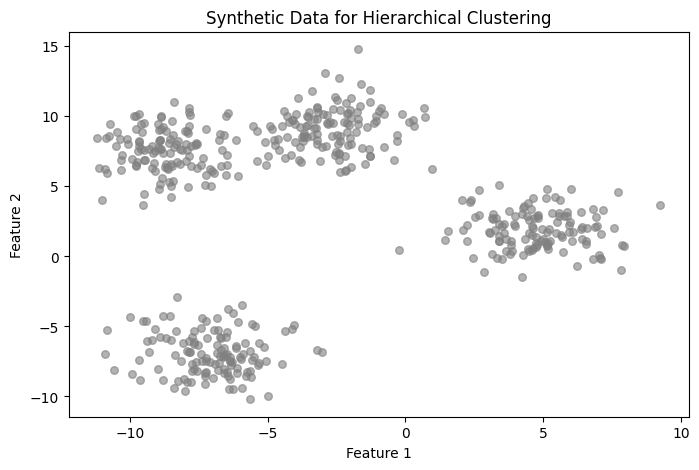

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Set seed for reproducibility
np.random.seed(42)

# 1. Generate Synthetic Data
# We create 4 clusters this time to make the hierarchy interesting
X, y_true = make_blobs(n_samples=500, centers=4, n_features=2, cluster_std=1.5, random_state=42)

# Visualize the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray', alpha=0.6)
plt.title("Synthetic Data for Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

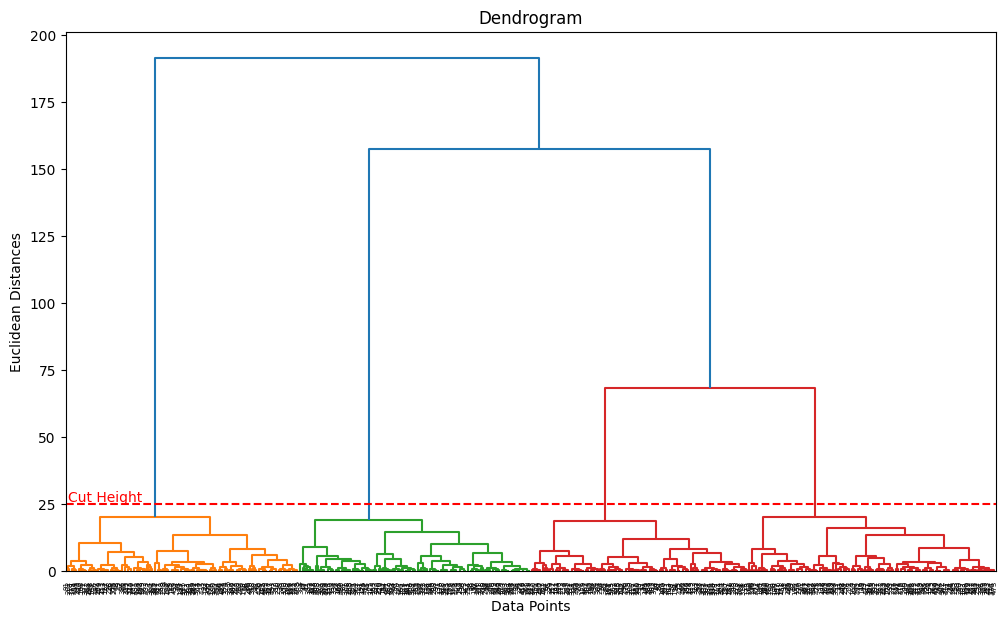

In [2]:
# 2. Plot the Dendrogram
# We use 'ward' linkage which minimizes variance within clusters
plt.figure(figsize=(12, 7))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distances")

# Create dendrogram using scipy
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))

# Add a horizontal line to show where we might 'cut' the tree
# Adjust the y-value (e.g., 25) based on the longest vertical lines
plt.axhline(y=25, color='r', linestyle='--')
plt.text(10, 26, 'Cut Height', color='red')

plt.show()

# Interpretation:
# The longest vertical lines that are not crossed by horizontal lines indicate
# the optimal number of clusters. In this plot, a cut at y=25 crosses 4 vertical lines,
# suggesting k=4 is the optimal number of clusters.

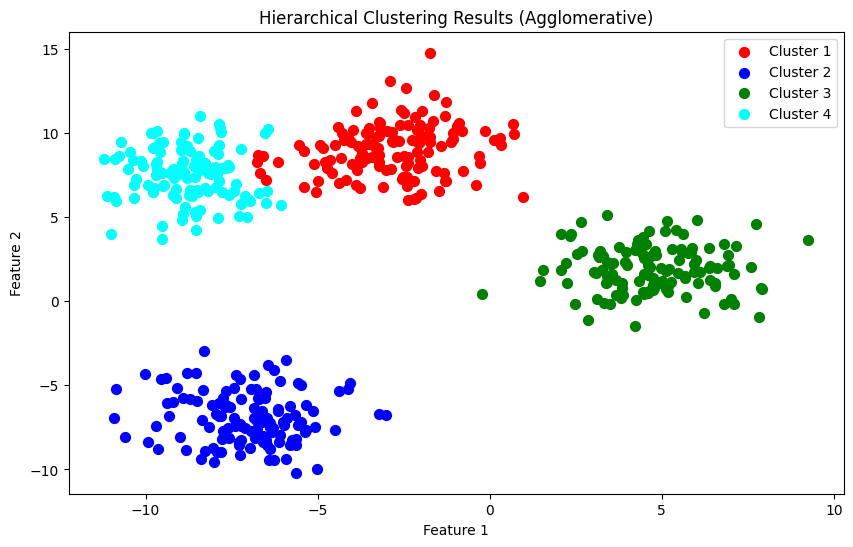

In [3]:
# 3. Fit Agglomerative Clustering
# Based on the dendrogram, we choose n_clusters=4
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')

# Fit and predict (assignments)
y_hc = hc.fit_predict(X)

# 4. Visualize the Clusters
plt.figure(figsize=(10, 6))

# Plot each cluster with a different color
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s=50, c='cyan', label='Cluster 4')

plt.title('Hierarchical Clustering Results (Agglomerative)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()